<h2>Readability and Unfairness in Terms of Service Documents</h2>
CSE 595 Course Project

Kristine McLaughlin

<h4>1. Data Preprocessing</h4>

In [2]:
import os
import re
import pandas as pd
import numpy as np

In [3]:
# Extract annotated clauses from tagged documents to build dataset
folder_path = 'TaggedDocuments_142'
data = []

for file in os.listdir(folder_path):
    file_path = os.path.join(folder_path, file)
    with open(file_path, "r", encoding="utf-8") as f:
        document_text = f.read()

    # Handling nested tags with a stack
    tag_stack = []
    buffer_text = ""
    clause_start = 0 # index where the clause text starts

    # Get all tags in document (open and close)
    tag_pattern = re.compile(r"<(/?)([a-zA-Z]+)(\d+)>") # <potential backslash, then letters, then a number>
    for tag in tag_pattern.finditer(document_text):
        tag_type = tag.group(1)  # '' for open, '/' for close
        category = tag.group(2)
        num = int(tag.group(3))
        tag_start, tag_end = tag.span() # start is index of tag start <, end is index after >

        # Opening tag - add tag to stack
        if tag_type == "":
            tag_stack.append((category, num))

        # Closing tag
        if tag_type == "/" and (category, num) in tag_stack:
            inner_text = document_text[clause_start:tag_start].strip().lower()

            if inner_text:  # only record if there’s text
                for category, num in tag_stack:
                    data.append({
                        "file_name": file,
                        "category": category,
                        "fairness_score": num,
                        "text": inner_text
                    })

            # Remove the matching tag from the stack
            if tag_stack and tag_stack[-1] == (category, num):
                tag_stack.pop()
            else:
                # Handle mismatched nesting by removing first occurrence
                if (category, num) in tag_stack:
                    tag_stack.remove((category, num))
        
        # Update where the text (should) start
        clause_start = tag_end

# Turn array into df
data = pd.DataFrame(data, columns=["file_name", "category", "fairness_score", "text"])
print(f"Extracted {len(data)} annotated clauses from {len(os.listdir(folder_path))} files")
print(data.head())

Extracted 3554 annotated clauses from 142 files
        file_name category  fairness_score  \
0  MyHeritage.xml      use               2   
1  MyHeritage.xml      use               2   
2  MyHeritage.xml       ch               2   
3  MyHeritage.xml      use               2   
4  MyHeritage.xml       cr               2   

                                                text  
0  please read them carefully, because by using t...  
1  if you do not agree with any provision in this...  
2  we reserve the right to modify any provision h...  
3  you agree to be bound to any changes to this a...  
4  we will not edit or monitor user-provided cont...  


In [4]:
# Manual check: Save to csv to investigate
data.to_csv("data.csv", index=False)

In [5]:
# Remove entries with fairness score of 4
data = data[data['fairness_score'] != 4]

In [6]:
# Get statistics on data
data.describe()

,fairness_score
count,3546.000000
mean,2.143542
std,0.463000
min,1.000000
25%,2.000000
50%,2.000000
75%,2.000000
max,3.000000


In [7]:
data['fairness_score'].value_counts()

fairness_score
2    2713
3     671
1     162
Name: count, dtype: int64

In [8]:
# First testing dataset just be the clearly fair (1) and clearly unfair (3) clauses
clear_fair = data[data['fairness_score'] == 1]
clear_unfair = data[data['fairness_score'] == 3]
data_clear = pd.concat([clear_fair, clear_unfair])

# Add binary fair/unfair value. 0 = fair, 1 = unfair
data_clear['unfair'] = (data_clear['fairness_score'] == 3).astype(int)

In [9]:
data_clear.describe()

,fairness_score,unfair
count,833.000000,833.000000
mean,2.611044,0.805522
std,0.792072,0.396036
min,1.000000,0.000000
25%,3.000000,1.000000
50%,3.000000,1.000000
75%,3.000000,1.000000
max,3.000000,1.000000


In [10]:
data_clear['unfair'].value_counts()

unfair
1    671
0    162
Name: count, dtype: int64

In [11]:
data_clear.head()

,file_name,category,fairness_score,text,unfair
57,Spotify.xml,ltd,1,nothing in the agreements removes or limits sp...,0
98,Xoom.xml,ltd,1,"paypal and you acknowledge that paypal, not ap...",0
150,Kardia.xml,ltd,1,"furthermore, nothing in these terms limits or ...",0
151,Kardia.xml,ltd,1,alivecor will be excused from performance unde...,0
154,Kardia.xml,j,1,"if you are a consumer located in the eu, such ...",0


<h4>2. Calculate Baselines</h4>

In [15]:
import textstat
import matplotlib.pyplot as plt

In [12]:
# Baseline 1: Random performance. Putting on scale of Flesch Reading Ease, 0-100
readability_baselines = data_clear.copy()
readability_baselines['random'] = np.random.uniform(0, 100, size=len(readability_baselines))
readability_baselines.head()

,file_name,category,fairness_score,text,unfair,random
57,Spotify.xml,ltd,1,nothing in the agreements removes or limits sp...,0,26.563507
98,Xoom.xml,ltd,1,"paypal and you acknowledge that paypal, not ap...",0,49.117628
150,Kardia.xml,ltd,1,"furthermore, nothing in these terms limits or ...",0,73.372864
151,Kardia.xml,ltd,1,alivecor will be excused from performance unde...,0,14.899969
154,Kardia.xml,j,1,"if you are a consumer located in the eu, such ...",0,33.111443


In [13]:
# Baseline 2: Traditional readability metrics
# Flesch Reading Ease, Flesch-Kincaid Grade Level, and Gunning Fog Index
def get_readability_scores(clause):
    flesch_ease = textstat.flesch_reading_ease(clause) # 0-100. Higher = easier
    flesch_kincaid = textstat.flesch_kincaid_grade(clause) # 0-~20. US grade level required. Higher = more difficult
    gunning_fog = textstat.gunning_fog(clause) # 0-~20. Years of education needed. Higher = more difficult
    
    return pd.Series({
        "flesch_ease": flesch_ease,
        "fk_grade": flesch_kincaid,
        "gunning_fog": gunning_fog
    })

In [16]:
# Apply function to the text column and create new df with those scores
scores = readability_baselines["text"].apply(get_readability_scores)
readability_baselines = pd.concat([readability_baselines, scores], axis=1)
readability_baselines.head()

,file_name,category,fairness_score,text,unfair,random,flesch_ease,fk_grade,gunning_fog
57,Spotify.xml,ltd,1,nothing in the agreements removes or limits sp...,0,26.563507,2.365517,20.133793,26.772414
98,Xoom.xml,ltd,1,"paypal and you acknowledge that paypal, not ap...",0,49.117628,-22.537857,33.792857,38.857143
150,Kardia.xml,ltd,1,"furthermore, nothing in these terms limits or ...",0,73.372864,16.496667,17.665926,21.170370
151,Kardia.xml,ltd,1,alivecor will be excused from performance unde...,0,14.899969,37.220000,18.005000,22.000000
154,Kardia.xml,j,1,"if you are a consumer located in the eu, such ...",0,33.111443,46.945000,11.680000,16.000000


In [17]:
# Investigate statistics on overall readability of dataset
readability_baselines.describe()

,fairness_score,unfair,random,flesch_ease,fk_grade,gunning_fog
count,833.000000,833.000000,833.000000,833.000000,833.000000,833.000000
mean,2.611044,0.805522,50.556068,26.145128,18.811845,21.862297
std,0.792072,0.396036,28.840026,29.469979,9.559456,10.143707
min,1.000000,0.000000,0.092229,-223.943436,2.470000,4.000000
25%,3.000000,1.000000,24.906557,11.130000,12.627143,15.485714
50%,3.000000,1.000000,50.513019,28.620690,16.674194,19.955556
75%,3.000000,1.000000,76.242388,45.000000,22.725000,26.130612
max,3.000000,1.000000,99.923009,95.688182,108.837761,114.565251


In [18]:
# Sort for visualization
baselines_sorted = readability_baselines.sort_values(by='flesch_ease', ascending=True)
baselines_sorted.head()

,file_name,category,fairness_score,text,unfair,random,flesch_ease,fk_grade,gunning_fog
2550,Bookingcom.xml,ltd,3,"however and to the extent permitted by law, ne...",1,45.135424,-223.943436,108.837761,114.565251
1155,Airbnb.xml,ltd,3,neither airbnb nor any other party involved in...,1,52.884713,-131.135000,78.254468,83.497872
1470,Crowdtangle.xml,ltd,3,with the exception of any acts or omissions of...,1,82.426433,-128.856429,72.968095,78.152381
3087,WeChat.xml,a,3,except to the extent that: (a) any applicable ...,1,98.495858,-102.207000,64.779333,69.600000
2841,VisaCashback.xml,j,1,"if you are a resident of (i) argentina, brazil...",0,98.269318,-84.437273,60.561818,65.032168


In [19]:
# Examining clause rated most unreadable across all baselines
baselines_sorted.iloc[0]['text']

'however and to the extent permitted by law, neither we nor any of our officers, directors, employees, representatives, subsidiaries, affiliated companies, distributors, affiliate (distribution) partners, licensees, agents or others involved in creating, sponsoring, promoting, or otherwise making available the site and its contents shall be liable for (i) any punitive, special, indirect or consequential loss or damages, any loss of production, loss of profit, loss of revenue, loss of contract, loss of or damage to goodwill or reputation, loss of claim, (ii) any inaccuracy relating to the (descriptive) information (including rates, availability and ratings) of the supplier as made available on our platform, (iii) the services rendered or the products offered by the supplier or other business partners, (iv) any (direct, indirect, consequential or punitive) damages, losses or costs suffered, incurred or paid by you, pursuant to, arising out of or in connection with the use, inability to u

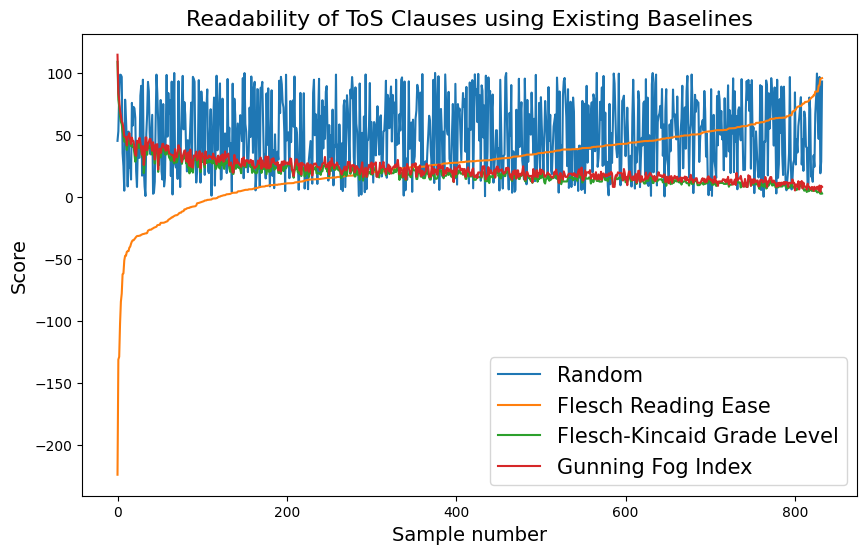

In [24]:
# Generate plot to visualize baseline trend
x = list(range(0, len(baselines_sorted)))
plt.figure(figsize=(10, 6))
plt.plot(x, baselines_sorted['random'].tolist(), label='Random')
plt.plot(x, baselines_sorted['flesch_ease'].tolist(), label='Flesch Reading Ease')
plt.plot(x, baselines_sorted['fk_grade'].tolist(), label='Flesch-Kincaid Grade Level')
plt.plot(x, baselines_sorted['gunning_fog'].tolist(), label='Gunning Fog Index')

plt.xlabel('Sample number', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.title('Readability of ToS Clauses using Existing Baselines', fontsize=16)

plt.legend(fontsize=15)
plt.show()

Graph visualization with highest 752 samples for Flesch Reading Ease


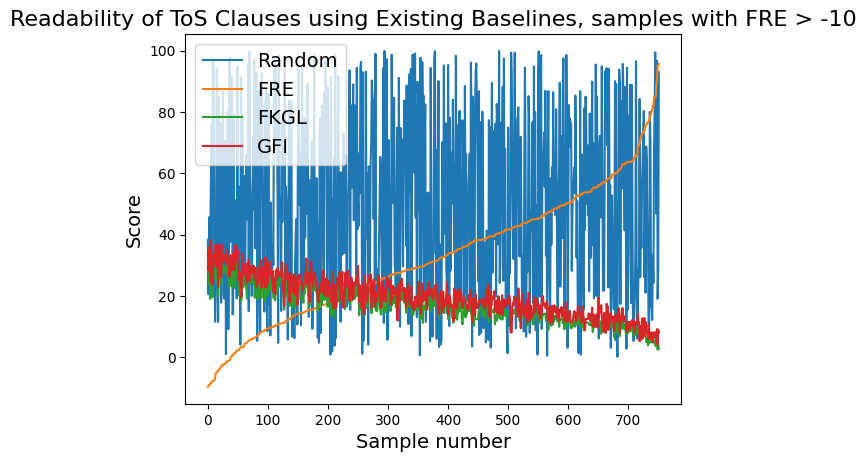

In [27]:
# Remove extreme samples to better visualize trend for majority of graph
baseline_cropped = baselines_sorted[baselines_sorted['flesch_ease'] > -10]

x = list(range(0, len(baseline_cropped)))
print("Graph visualization with highest", len(baseline_cropped), "samples for Flesch Reading Ease")
plt.plot(x, baseline_cropped['random'].tolist(), label='Random')
plt.plot(x, baseline_cropped['flesch_ease'].tolist(), label='FRE')
plt.plot(x, baseline_cropped['fk_grade'].tolist(), label='FKGL')
plt.plot(x, baseline_cropped['gunning_fog'].tolist(), label='GFI')

plt.xlabel('Sample number', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.title('Readability of ToS Clauses using Existing Baselines, samples with FRE > -10', fontsize=16)

plt.legend(fontsize=14)
plt.show()